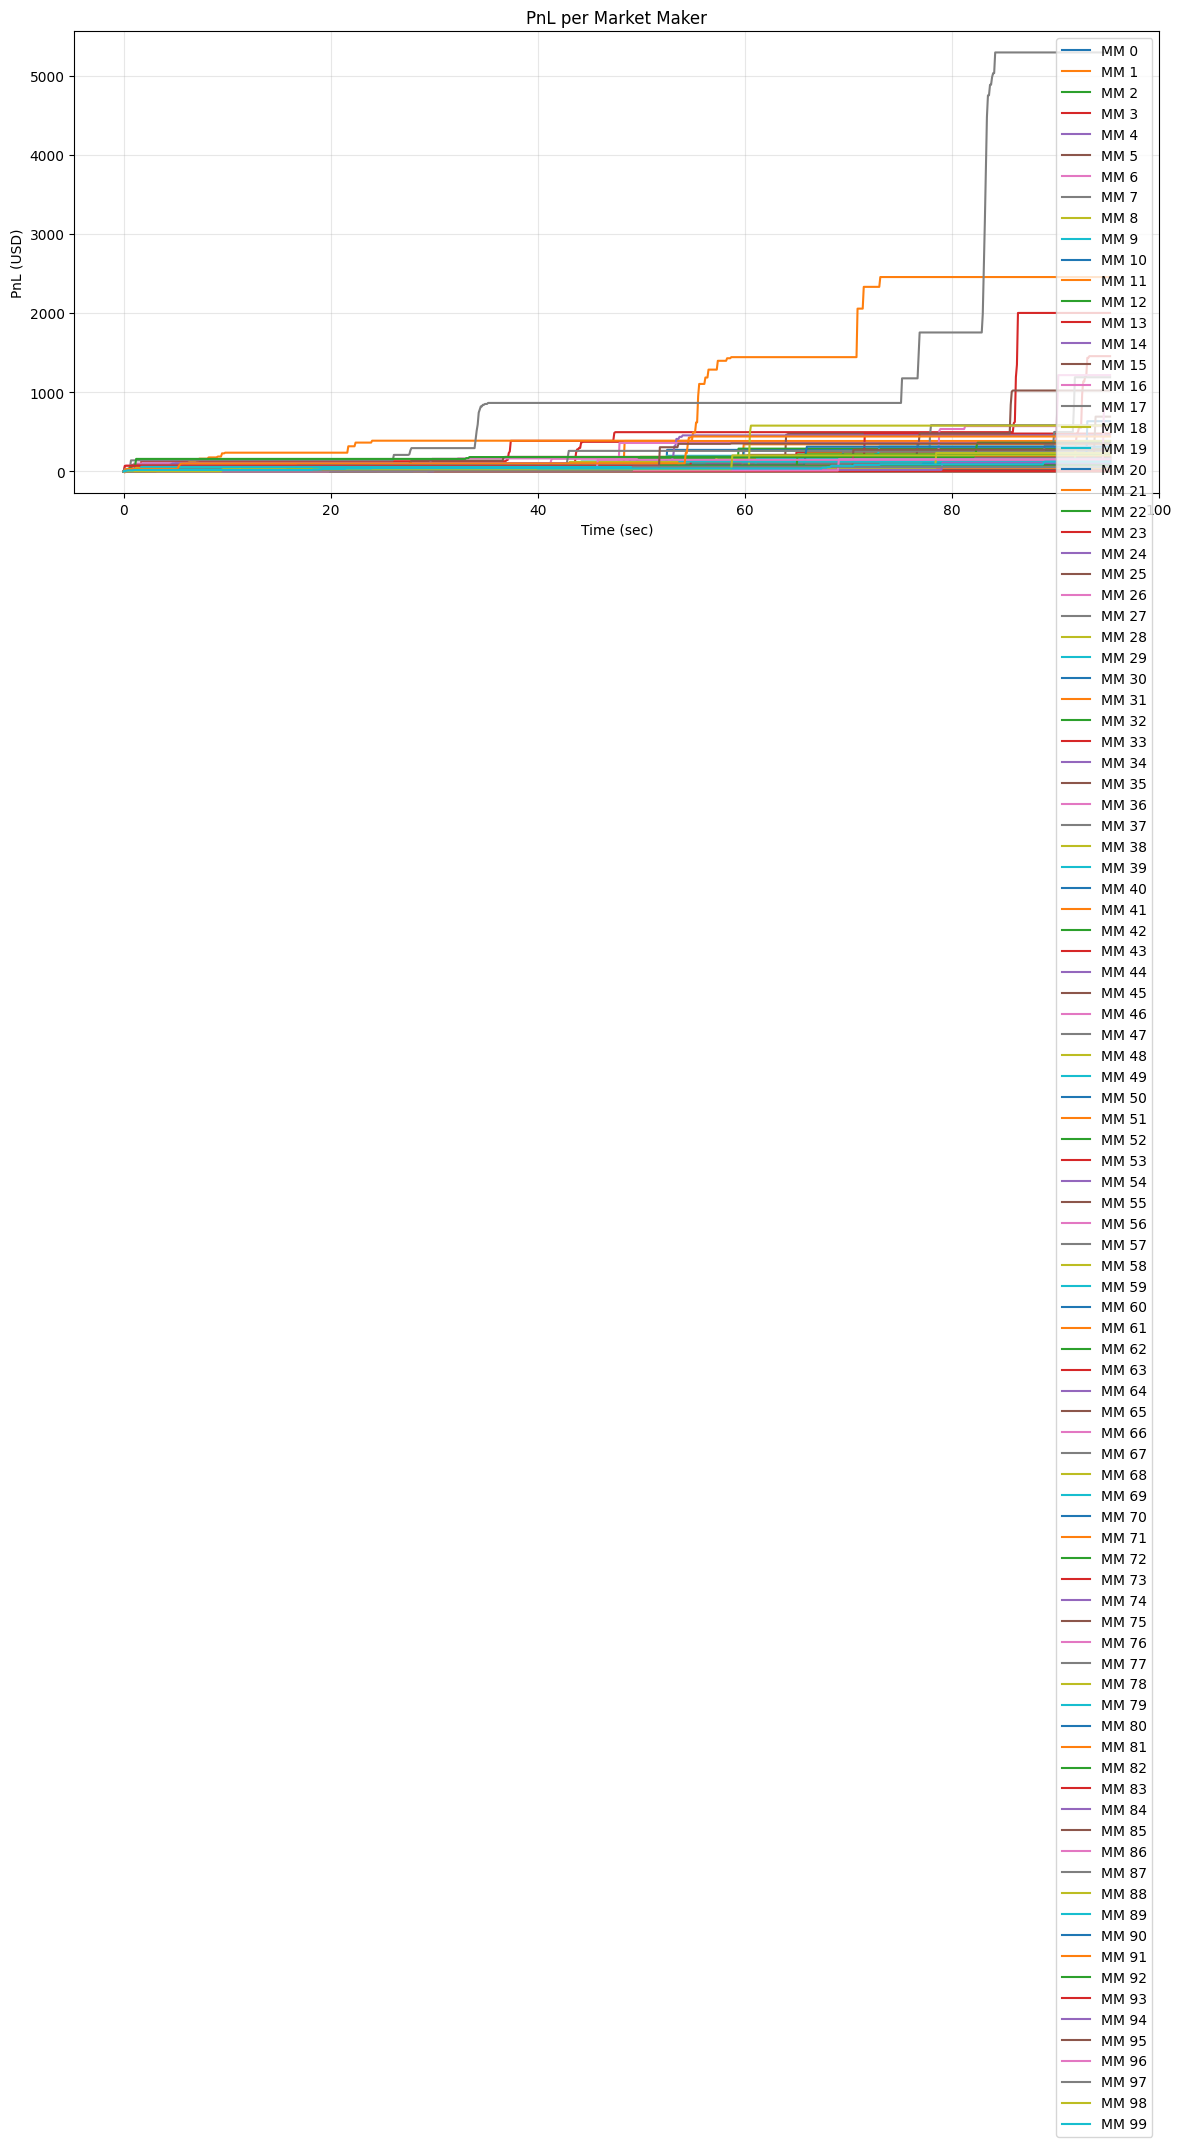

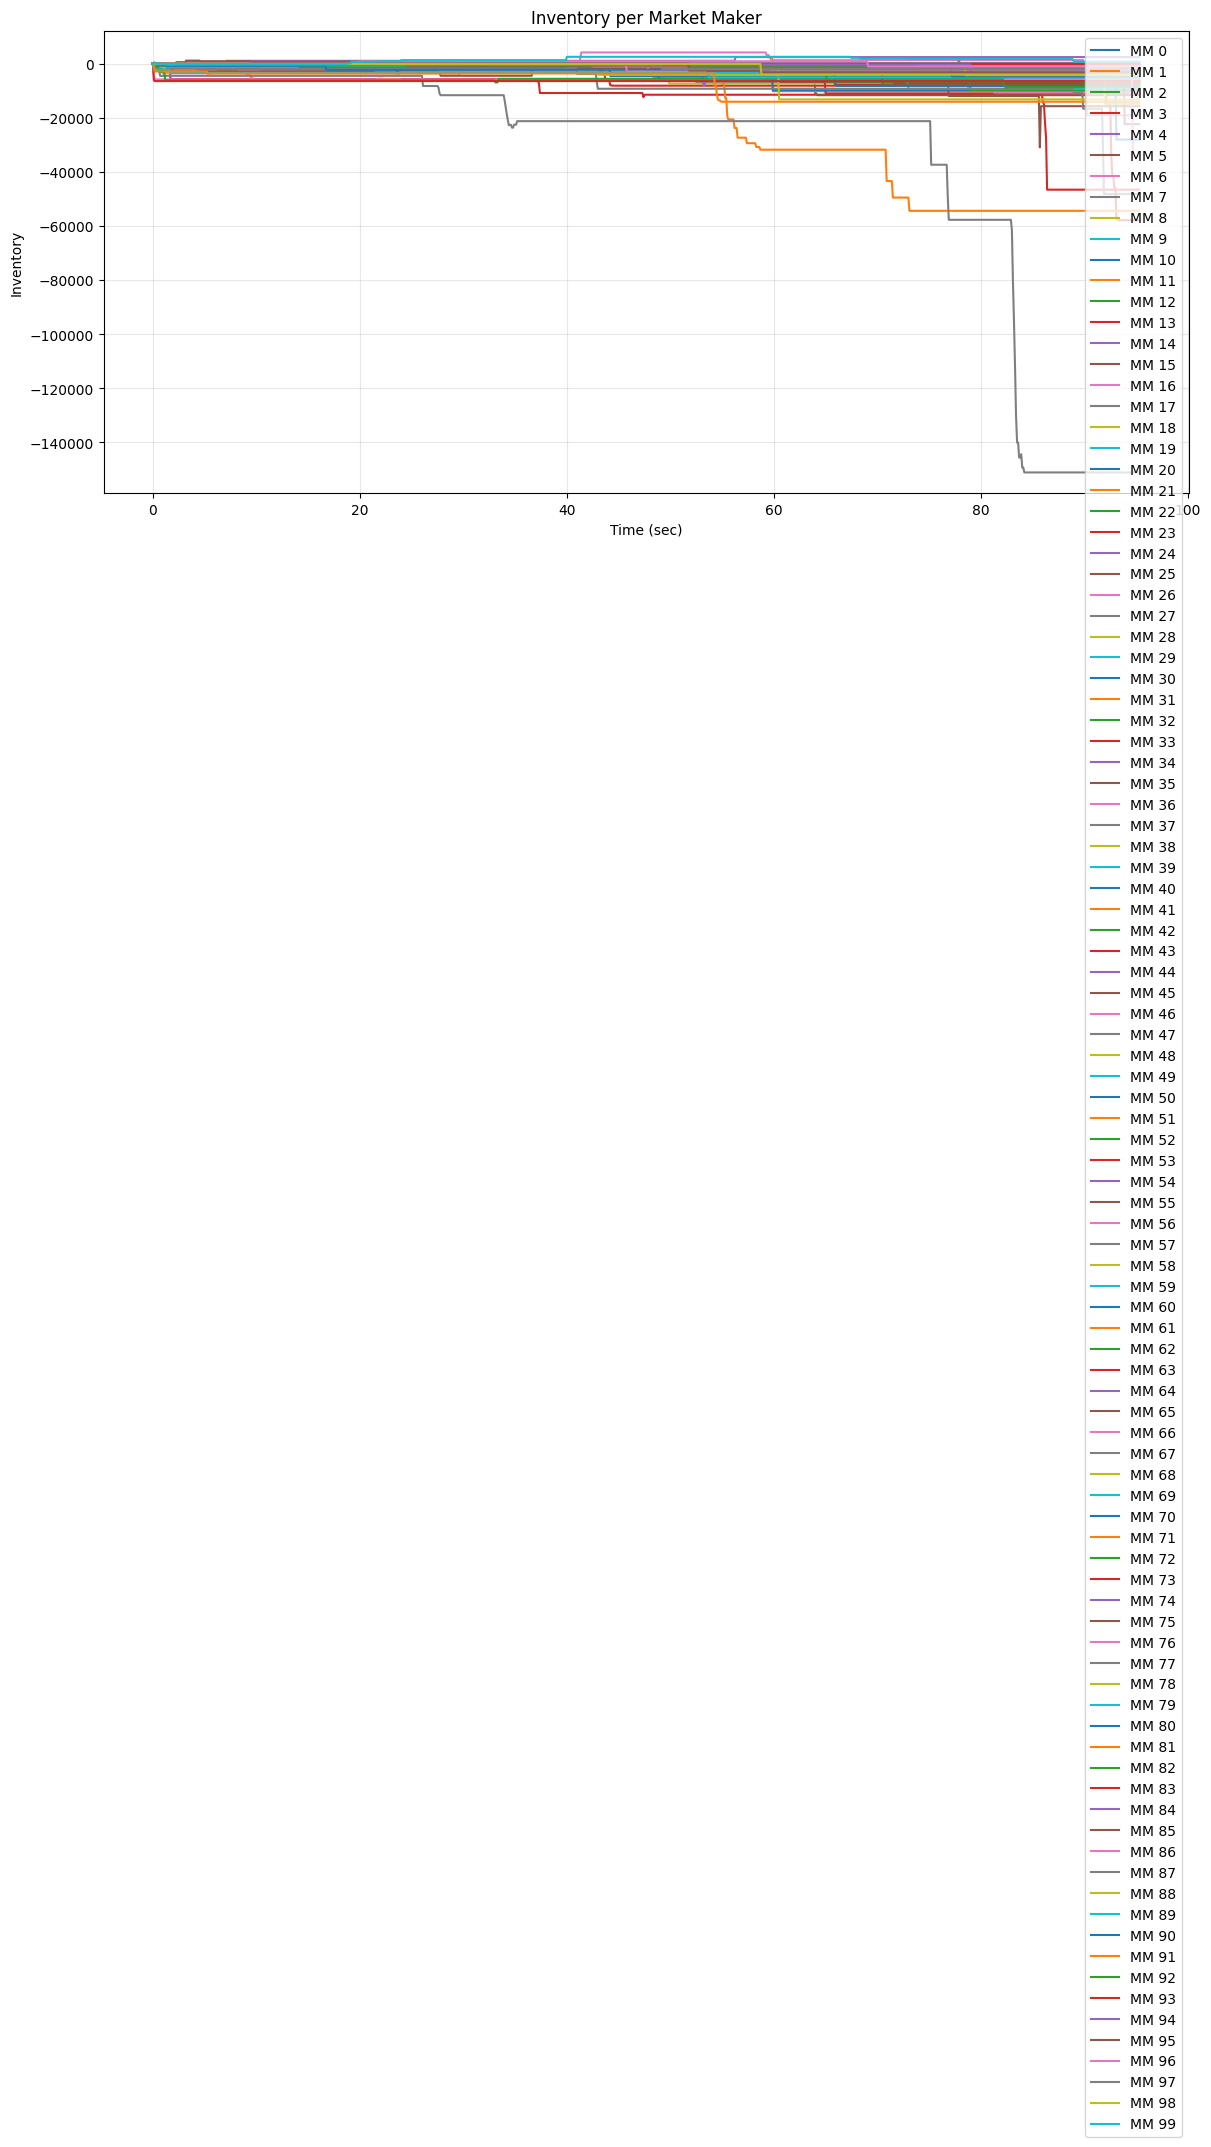

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Load data
df = pd.read_csv("sim_pnl.csv")   # or whatever filename is

# Convert time
start = df['sim_time_ns'].iloc[0]
df['time_sec'] = (df['sim_time_ns'] - start) / 1e9

# ---- 1. Plot PnL per market maker ----
plt.figure(figsize=(14,6))

for mm in df['mm_id'].unique():
    subset = df[df['mm_id'] == mm]
    plt.plot(subset['time_sec'], subset['mtm_pnl_usd'], label=f"MM {mm}")

plt.title("PnL per Market Maker")
plt.xlabel("Time (sec)")
plt.ylabel("PnL (USD)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


# ---- 2. Plot Inventory per market maker ----
plt.figure(figsize=(14,6))

for mm in df['mm_id'].unique():
    subset = df[df['mm_id'] == mm]
    plt.plot(subset['time_sec'], subset['inventory'], label=f"MM {mm}")

plt.title("Inventory per Market Maker")
plt.xlabel("Time (sec)")
plt.ylabel("Inventory")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [2]:
final_pnl = df.groupby('mm_id')['mtm_pnl_usd'].last().sort_values()
print(final_pnl)

inv_risk = df.groupby('mm_id')['inventory'].std()
pnl = df.groupby('mm_id')['mtm_pnl_usd'].last()

analysis = pd.DataFrame({
    "pnl": pnl,
    "inventory_risk": inv_risk
})

print(analysis.sort_values("pnl"))

mm_id
2        0.00
57       0.00
48       0.00
44       0.00
93       0.00
       ...   
6     1216.55
3     1456.18
13    2002.11
31    2455.44
37    5292.70
Name: mtm_pnl_usd, Length: 100, dtype: float64
           pnl  inventory_risk
mm_id                         
2         0.00        0.000000
57        0.00        0.000000
48        0.00        0.000000
44        0.00        0.000000
93        0.00        0.000000
...        ...             ...
6      1216.55     4996.905456
3      1456.18     9187.456156
13     2002.11    11440.248831
31     2455.44    20895.037057
37     5292.70    46018.799983

[100 rows x 2 columns]


In [3]:
analysis["pnl_per_risk"] = analysis["pnl"] / (analysis["inventory_risk"] + 1e-6)
print(analysis.sort_values("pnl_per_risk", ascending=False))
print(analysis.corr())

          pnl  inventory_risk  pnl_per_risk
mm_id                                      
54     455.40      683.598452      0.666181
32     287.65      437.993506      0.656745
39      17.34       40.513807      0.428002
14     102.99      252.010141      0.408674
81      46.71      122.650255      0.380839
...       ...             ...           ...
44       0.00        0.000000      0.000000
57       0.00        0.000000      0.000000
48       0.00        0.000000      0.000000
90       0.00        0.000000      0.000000
93       0.00        0.000000      0.000000

[100 rows x 3 columns]
                     pnl  inventory_risk  pnl_per_risk
pnl             1.000000        0.964529     -0.006562
inventory_risk  0.964529        1.000000     -0.148202
pnl_per_risk   -0.006562       -0.148202      1.000000
